In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Big plot fonts 
def bigTicks(axs=None, size=12):
    '''Increase font size of "tick" labels, including the exponential offset'''
    if(axs is None):
        ax = plt.gca()
        ax.tick_params(axis='both', which='major', labelsize=size)
        ax.yaxis.get_offset_text().set_size(size)
    else:
        for ax in axs:
            ax.tick_params(axis='both', which='major', labelsize=size)
            ax.yaxis.get_offset_text().set_size(size)

def bigLabels(axs=None, size=14):
    '''Force axes labels to size.'''
    if(axs is None):
        ax = plt.gca()
        lbl_x, lbl_y = ax.get_xlabel(), ax.get_ylabel()
        ax.set_xlabel(lbl_x, size=size)
        ax.set_ylabel(lbl_y, size=size)
    else:
        for ax in axs:
            lbl_x, lbl_y = ax.get_xlabel(), ax.get_ylabel()
            ax.set_xlabel(lbl_x, size=size)
            ax.set_ylabel(lbl_y, size=size)

In [18]:
F3 = f[np.argmin(np.abs(dB - np.max(dB) + 3))]
F3

62984.2

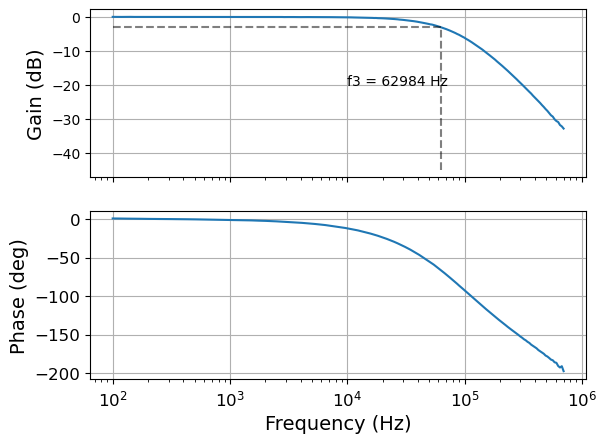

In [27]:
fig, (ax1, ax2) = plt.subplots(2, sharex=True)

dat = np.loadtxt('scope_6.csv', skiprows=1, delimiter=',', encoding='cp1252')
i, f, amp, dB, phi = np.transpose(dat)
dB = dB - np.max(dB)
ax1.semilogx(f, dB)

#dat = np.loadtxt('scope_7.csv', skiprows=1, delimiter=',', encoding='cp1252')
#i, f, amp, dB, phi = np.transpose(dat)
#ax1.semilogx(f, dB)

dat = np.loadtxt('scope_6.csv', skiprows=1, delimiter=',', encoding='cp1252')
i, f, amp, dB, phi = np.transpose(dat)
ax2.semilogx(f, phi-180)

#dat = np.loadtxt('scope_7.csv', skiprows=1, delimiter=',', encoding='cp1252')
#i, f, amp, dB, phi = np.transpose(dat)
#ax2.semilogx(f, phi)

ax1.set_ylabel("Gain (dB)")
ax2.set_ylabel("Phase (deg)")
ax2.set_xlabel("Frequency (Hz)")

ax1.grid()
ax2.grid();

ax1.hlines([-3], np.min(f), F3, color='k', ls='--', alpha=0.5)
ax1.vlines([F3], -45, -3, color='k', ls='--', alpha=0.5)

ax1.annotate(f"f3 = {int(F3)} Hz", (1e4, -20))

bigTicks(); bigLabels((ax1, ax2))

plt.savefig("BodePlot.pdf", bbox_inches='tight')

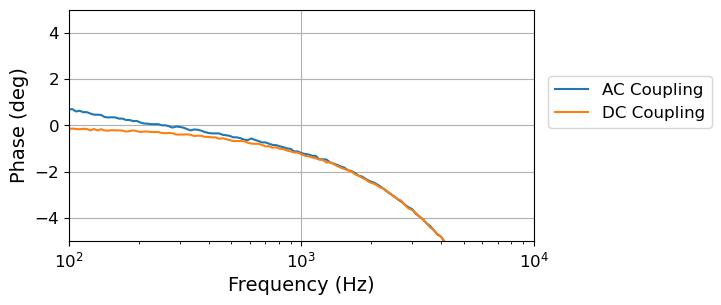

In [8]:
plt.figure(figsize=(6,3))

dat = np.loadtxt('scope_6.csv', skiprows=1, delimiter=',', encoding='cp1252')
i, f, amp, dB, phi = np.transpose(dat)
plt.semilogx(f, phi-180, label='AC Coupling')

dat = np.loadtxt('scope_7.csv', skiprows=1, delimiter=',', encoding='cp1252')
i, f, amp, dB, phi = np.transpose(dat)
plt.semilogx(f, phi-180, label='DC Coupling')

plt.ylim(-5, 5)
plt.xlim(1e2, 1e4)

plt.grid() 

plt.ylabel("Phase (deg)")
plt.xlabel("Frequency (Hz)")
plt.legend(fontsize=12, bbox_to_anchor=(1.4, 0.75))

bigTicks(); bigLabels()
plt.savefig("acdcPhase.pdf", bbox_inches='tight')